In [1]:
import pandas as pd

# Load combined dataset
df = pd.read_csv("../data/combined.csv")
print(df.shape)
print(df.head())
print(df['label'].value_counts())


(99592, 2)
                                                text  label
0  lilly corona estelabalticpinaabcgallerycom loo...      1
1  truett bundynoopputiagccom earth biography htt...      1
2  carlos e r vyjwdtrpcautelefonicanet begin pgp ...      0
3  cristian garry bluewisasanitaircom dear c202f8...      1
4  hi mrs vorke idaho plot 13 victoria garden cit...      1
label
0    50208
1    49384
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

# Split into training data (80%) & testing data (20%)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=2025, stratify=df["label"]
)
# Split into training data again into training data (90%) and validation set (10%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.1, random_state=2025, stratify=train_labels
)
# Training data (72%) & validation (8%) and testing (20%)
print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")


Train: 71705 | Val: 7968 | Test: 19919


In [3]:
from pathlib import Path
Path("../data/splits").mkdir(parents=True, exist_ok=True)

# Save the splitted dataset so we can reuse it later
pd.DataFrame({"text": train_texts, "label": train_labels}).to_csv("../data/splits/train.csv", index=False)
pd.DataFrame({"text": val_texts, "label": val_labels}).to_csv("../data/splits/val.csv", index=False)
pd.DataFrame({"text": test_texts, "label": test_labels}).to_csv("../data/splits/test.csv", index=False)


In [4]:
from transformers import BertTokenizer

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Turn all texts into strings
train_texts = list(map(str, train_texts))
val_texts   = list(map(str, val_texts))
test_texts  = list(map(str, test_texts))

# Tokenize the training, validation and testing data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings   = tokenizer(val_texts, truncation=True, padding=True, max_length=256)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=256)



In [5]:
import torch
# Custom Dataset class
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings # Store the tokenized input data
        self.labels = labels # Store the corresponding labels

    def __len__(self):
        return len(self.labels) # Return the total number of samples in the dataset

    def __getitem__(self, idx): # For a given index, retrieve the input tokens and their label
        
        # Each tensor corresponds to one sample (row) from the tokenized data
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels.iloc[idx])) # Add the label
        return item
        
# Create 3 datasets
train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)
test_dataset = EmailDataset(test_encodings, test_labels)


In [6]:
from transformers import BertForSequenceClassification

# Load BERT model for binary classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


2025-10-16 01:30:42.776257: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-16 01:30:42.807216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 01:30:43.731635: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of BertForSequenceClassification were not initialized from the model checkpoin

In [7]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)   # Predicted class
    
    # Compute precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    # Compute overall accuracy
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [8]:
from transformers import Trainer, TrainingArguments, BertForSequenceClassification
import numpy as np

# Define a function that returns a fresh BERT model for each trial
def model_init():
    return BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Define the base training arguments
training_args = TrainingArguments(
    output_dir="./results_tuned", # Where to save model checkpoints & logs
    eval_strategy="epoch", # Evaluate model checkpoints after each epoch
    save_strategy="epoch", # Save model checkpoints after each epoch
    load_best_model_at_end=True, # Load the best model based on eval metric
    metric_for_best_model="f1", # Use F1-score as the selection metric
    logging_dir="./logs_tuned",
)

# Create the Trainer object
trainer = Trainer(
    model_init=model_init,
    args=training_args, # Training configurations
    train_dataset=train_dataset, # Use the Training Dataset
    eval_dataset=val_dataset, # Use the Validation Dataset
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
import optuna
import os

# Define target study and path
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")
study_name = "bert_tuning"

# Ensure directory exists
os.makedirs(os.path.dirname(db_path), exist_ok=True)
print("DB path:", db_path)

# Try loading an existing study; create a new one if not found
try:
    study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")
    print(f"Loaded existing study: '{study_name}' with {len(study.trials)} trials.")
except KeyError:
    print(f"Study '{study_name}' not found. Creating a new one...")
    study = optuna.create_study(study_name=study_name, storage=f"sqlite:///{db_path}", direction="maximize")
    print(f"New study '{study_name}' created at {db_path}.")

# Print all completed trials for reference
print(f"\nFinished trials: {len(study.trials)}")
for t in study.trials:
    print(f"Trial {t.number}: value={t.value}, params={t.params}")


DB path: /home/nmd/projects/phishing-detector/notebooks/tuning_checkpoints/bert_tuning.db
Loaded existing study: 'bert_tuning' with 8 trials.

Finished trials: 8
Trial 0: value=2.654691949272044, params={'learning_rate': 0.00013634326091887096, 'num_train_epochs': 4, 'per_device_train_batch_size': 32}
Trial 1: value=0.5041415662650602, params={'learning_rate': 0.0001847906425515326, 'num_train_epochs': 5, 'per_device_train_batch_size': 8}
Trial 2: value=2.654691949272044, params={'learning_rate': 0.00012449977830485183, 'num_train_epochs': 5, 'per_device_train_batch_size': 8}
Trial 3: value=0.5041415662650602, params={'learning_rate': 0.00033948722617453605, 'num_train_epochs': 3, 'per_device_train_batch_size': 16}
Trial 4: value=2.654691949272044, params={'learning_rate': 7.18369614742746e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 8}
Trial 5: value=3.9863517795387007, params={'learning_rate': 5.1196576269375056e-05, 'num_train_epochs': 3, 'per_device_train_batch_size':

In [10]:
import os

# Construct the absolute path for the SQLite file
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")

# Define how Optuna should explore hyperparameters
def optuna_hp_space(trial):
    return {
        # Sample a learning rate between 1e-5 and 5e-4
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        
        # Try 3, 4, or 5 epochs per training trial
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 5),
        
        # Try different batch sizes for training
        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size", [8, 16, 32]
        ),
    }

# Run automatic hyperparameter tuning using Optuna
best_run = trainer.hyperparameter_search(
    direction="maximize", # Success criteria: we want to maximize F1-score
    backend="optuna", # Use Optuna as the tuning backend
    n_trials=20, # Try to rerun the experiment X times, adjust it appropriately
    hp_space=optuna_hp_space,
    study_name="bert_tuning",  # Name of the study
    storage=f"sqlite:///{db_path}",  # Save to this DB file
    load_if_exists=True,
)

print("Best hyperparameters found:")
print(best_run.hyperparameters)

[I 2025-10-16 01:30:45,366] Using an existing study with name 'bert_tuning' instead of creating a new one.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.036100,0.028213,0.992972,0.989937,0.995950,0.992935
2,0.013900,0.018526,0.995482,0.995194,0.995697,0.995445
3,0.003100,0.022070,0.995858,0.996452,0.995191,0.995821


[I 2025-10-16 02:30:54,519] Trial 8 finished with value: 3.983322825917118 and parameters: {'learning_rate': 1.5714393561955377e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 32}. Best is trial 5 with value: 3.9863517795387007.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.704400,0.696160,0.495858,0.495858,1.000000,0.662975
2,0.698000,0.694559,0.504142,0.000000,0.000000,0.000000
3,0.694300,0.693123,0.504142,0.000000,0.000000,0.000000


/home/nmd/projects/phishing-detector/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nmd/projects/phishing-detector/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2025-10-16 03:36:27,197] Trial 9 finished with value: 0.5041415662650602 and parameters: {'learning_rate': 0.0002884543116115514, 'num_train_epochs': 3, 'per_device_train_batch_size': 8}. Best is trial 5 with value: 3.9863517795387007.
Some weights of BertForSequenceClassification were not initialized from t

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.700900,0.693328,0.504142,0.000000,0.000000,0.000000


/home/nmd/projects/phishing-detector/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2025-10-16 18:16:49,118] Trial 26 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.706300,0.693293,0.504142,0.000000,0.000000,0.000000


/home/nmd/projects/phishing-detector/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2025-10-16 18:36:30,521] Trial 27 pruned. 


Best hyperparameters found:
{'learning_rate': 2.9826081423769977e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 32}


In [11]:
import optuna

# Construct absolute path to the database
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")

# Load the Optuna study
study = optuna.load_study(
    study_name="bert_tuning",  # Load in the study
    storage=f"sqlite:///{db_path}" # Load from the DB file
)

# Get the best parameters and F1 value
best_params = study.best_params 
best_value = study.best_value

print("Best hyperparameters found:", best_params)
print(f"Best F1 score: {best_value:.4f}")

Best hyperparameters found: {'learning_rate': 2.9826081423769977e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 32}
Best F1 score: 3.9869


In [12]:
# Load in using the best hyperparameter found
training_args = TrainingArguments(
    output_dir="./results_final", # Where to save model checkpoints & logs
    eval_strategy="epoch", # Evaluate model checkpoints after each epoch
    save_strategy="epoch", # Save model checkpoints after each epoch
    load_best_model_at_end=True, # Load the best model based on eval metric
    metric_for_best_model="f1",
    learning_rate=best_params["learning_rate"], # Set the learning rate to the best one it has found
    num_train_epochs=int(best_params["num_train_epochs"]), # Set the number of epochs to the best one it has found
    per_device_train_batch_size=int(best_params["per_device_train_batch_size"]), # Set the batch size to the best one it has found
    logging_dir="./logs_final",
)

# Create the Trainer object
trainer = Trainer(
    model=model_init(),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# Training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.036900,0.025965,0.993474,0.994923,0.991901,0.993409
2,0.011400,0.021344,0.995733,0.996451,0.994938,0.995694
3,0.001500,0.021787,0.996486,0.996708,0.996203,0.996456


TrainOutput(global_step=6723, training_loss=0.02629213430298841, metrics={'train_runtime': 3553.2011, 'train_samples_per_second': 60.541, 'train_steps_per_second': 1.892, 'total_flos': 2.82995673368832e+16, 'train_loss': 0.02629213430298841, 'epoch': 3.0})

In [14]:
# Save the newly trained Bert model
trainer.save_model("../models/saved_model")
tokenizer.save_pretrained("../models/saved_model")

('../models/saved_model/tokenizer_config.json',
 '../models/saved_model/special_tokens_map.json',
 '../models/saved_model/vocab.txt',
 '../models/saved_model/added_tokens.json')

In [15]:
# Evaluate the new model with the test_dataset
results = trainer.evaluate(test_dataset)
print("Test Results:", results)


Test Results: {'eval_loss': 0.02380935102701187, 'eval_accuracy': 0.9957327175058989, 'eval_precision': 0.9957472660996355, 'eval_recall': 0.995646451351625, 'eval_f1': 0.9956968561737458, 'eval_runtime': 102.9219, 'eval_samples_per_second': 193.535, 'eval_steps_per_second': 24.193, 'epoch': 3.0}


Test Results: {'eval_loss': 0.02380935102701187, 'eval_accuracy': 0.9957327175058989, 'eval_precision': 0.9957472660996355, 'eval_recall': 0.995646451351625, 'eval_f1': 0.9956968561737458, 'eval_runtime': 104.3219, 'eval_samples_per_second': 190.938, 'eval_steps_per_second': 23.868, 'epoch': 3.0}


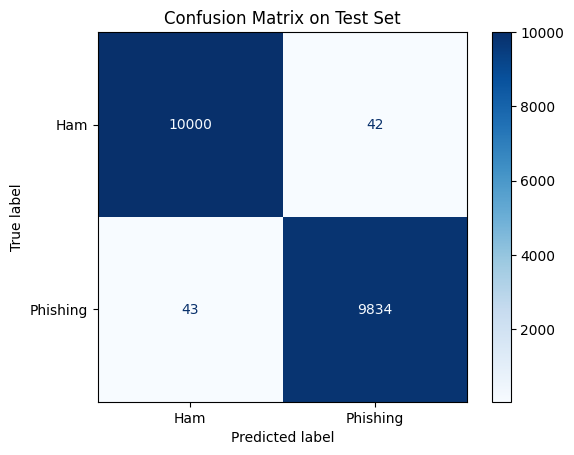

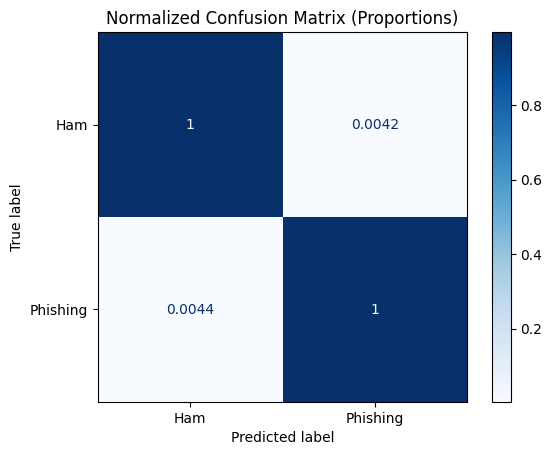

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import json

# Evaluate
results = trainer.evaluate(test_dataset)
print("Test Results:", results)

# Predictions
preds_output = trainer.predict(test_dataset) # Get model outputs
preds = preds_output.predictions.argmax(-1) # Convert logits to predicted class indices
labels = preds_output.label_ids # True labels from the dataset

# Generate a detailed classification report
report = classification_report(labels, preds, target_names=["Ham", "Phishing"], output_dict=True)
results.update(report)

# Save all results (metrics and report) into a JSON file
with open("../notebooks/test_results.json", "w") as f:
    json.dump(results, f, indent=4)

# Raw Confusion Matrix
cm = confusion_matrix(labels, preds)  # Compute confusion matrix from predictions and true labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.savefig("../notebooks/confusion_matrix_raw.png", bbox_inches="tight", dpi=300) # Save figure
plt.show() # Display

# Normalized Confusion Matrix
cm_norm = confusion_matrix(labels, preds, normalize="true") # Normalize by true label counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Ham", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Normalized Confusion Matrix (Proportions)")
plt.savefig("../notebooks/confusion_matrix_normalized.png", bbox_inches="tight", dpi=300) # Save normalized version of the confusion map
plt.show() # Display
